# Project results.

The purpose of this notebook is to present the results of the project and highlight the most important results.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [2]:
df = pd.read_csv("collected_metrics.csv")

In [4]:
# Extract processing type ('top' vs 'dim_red') into a new column for faceting
df['processing_type'] = df['model_name'].apply(
    lambda x: 'Top Features' if 'top' in x else 'Dimensionality Reduction'
)

# 3. Standardize capitalization in feature_type for cleaner axis labels
df['feature_type'] = df['feature_type'].str.capitalize()
df['feature_type'] = df['feature_type'].replace('Tfidf', 'TF-IDF')

# 4. Define a consistent color palette for the classifiers
clf_palette = {
    'LinearSVC': '#1f77b4', 
    'LogisticRegression': '#ff7f0e', 
    'XGBoost': '#2ca02c'
}

sns.set_theme(style="whitegrid")

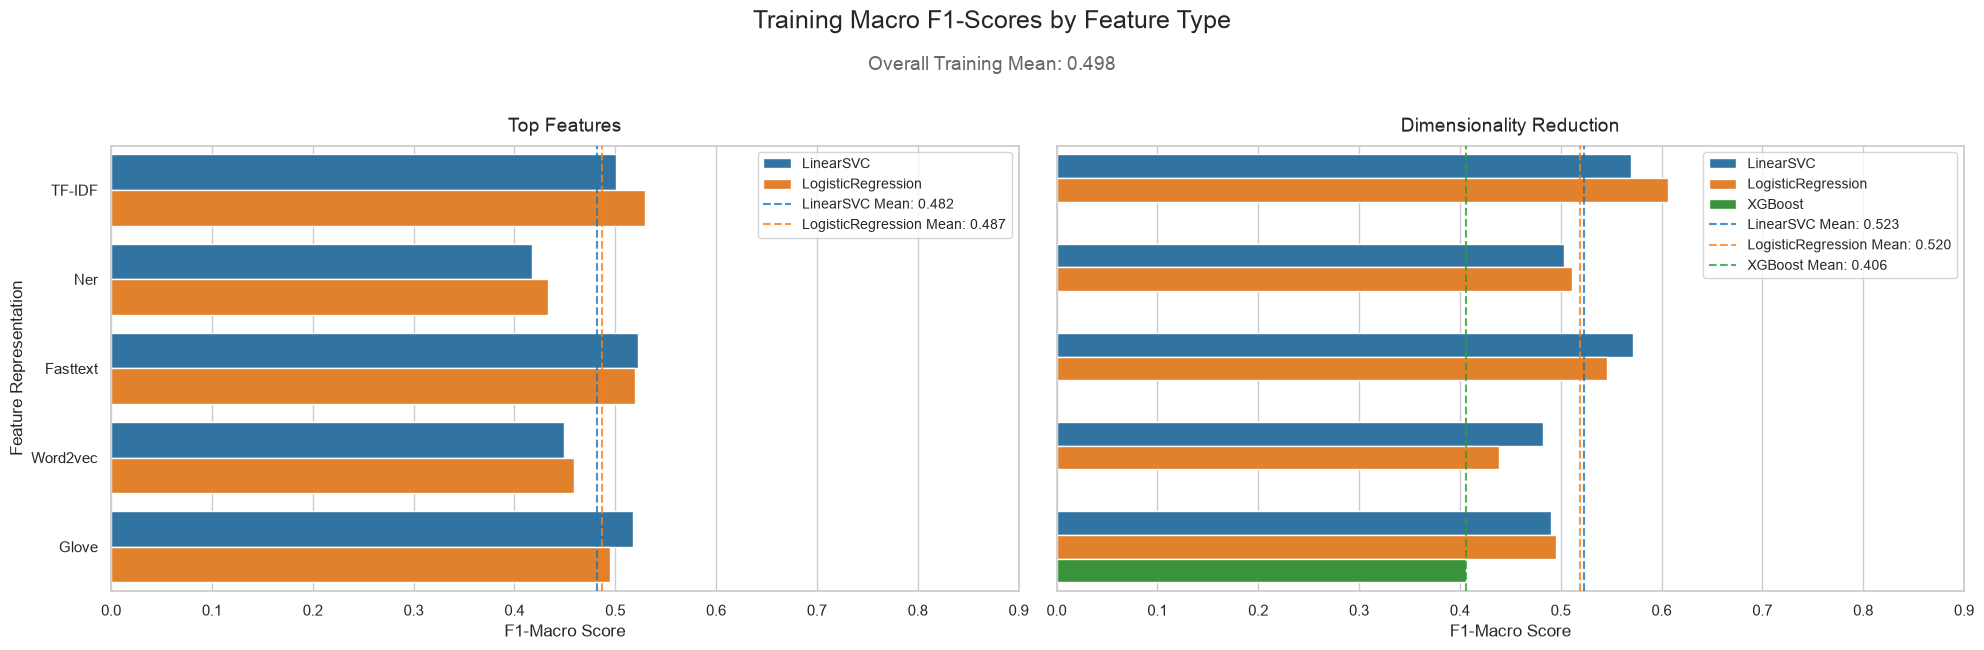

In [12]:
# ==========================================
# PLOT 1: TRAINING F1-MACRO SCORES
# ==========================================
train_df = df[df['mode'] == 'training'].copy()
overall_train_mean = train_df['f1_macro'].mean()

fig1, axes1 = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Main Title and Overall Mean Caption
fig1.suptitle('Training Macro F1-Scores by Feature Type', fontsize=18, y=1.08)
fig1.text(0.5, 0.98, f"Overall Training Mean: {overall_train_mean:.3f}", ha='center', fontsize=14, color='dimgray')

for idx, proc_type in enumerate(['Top Features', 'Dimensionality Reduction']):
    subset = train_df[train_df['processing_type'] == proc_type]
    
    # Plot the horizontal bar chart
    sns.barplot(
        data=subset, 
        y='feature_type', 
        x='f1_macro', 
        hue='classifier', 
        palette=clf_palette,
        ax=axes1[idx]
    )
    
    # Calculate and plot the mean vertical line per classifier
    for clf in subset['classifier'].unique():
        clf_mean = subset[subset['classifier'] == clf]['f1_macro'].mean()
        axes1[idx].axvline(
            x=clf_mean, 
            color=clf_palette[clf], 
            linestyle='--', 
            alpha=0.8, 
            zorder=3,
            label=f'{clf} Mean: {clf_mean:.3f}' # Adds the line value to the legend
        )
    
    # Formatting
    axes1[idx].set_title(proc_type, fontsize=14, pad=10)
    axes1[idx].set_xlabel('F1-Macro Score', fontsize=12)
    axes1[idx].set_xlim(0, 0.9) 
    
    # Update legend to include both the bars and our new mean lines
    handles, labels = axes1[idx].get_legend_handles_labels()
    axes1[idx].legend(handles, labels, loc='upper right', fontsize=10)
    
axes1[0].set_ylabel('Feature Representation', fontsize=12)
axes1[1].set_ylabel('')

plt.tight_layout()
plt.savefig(
    "../plots/model_training_visuals.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

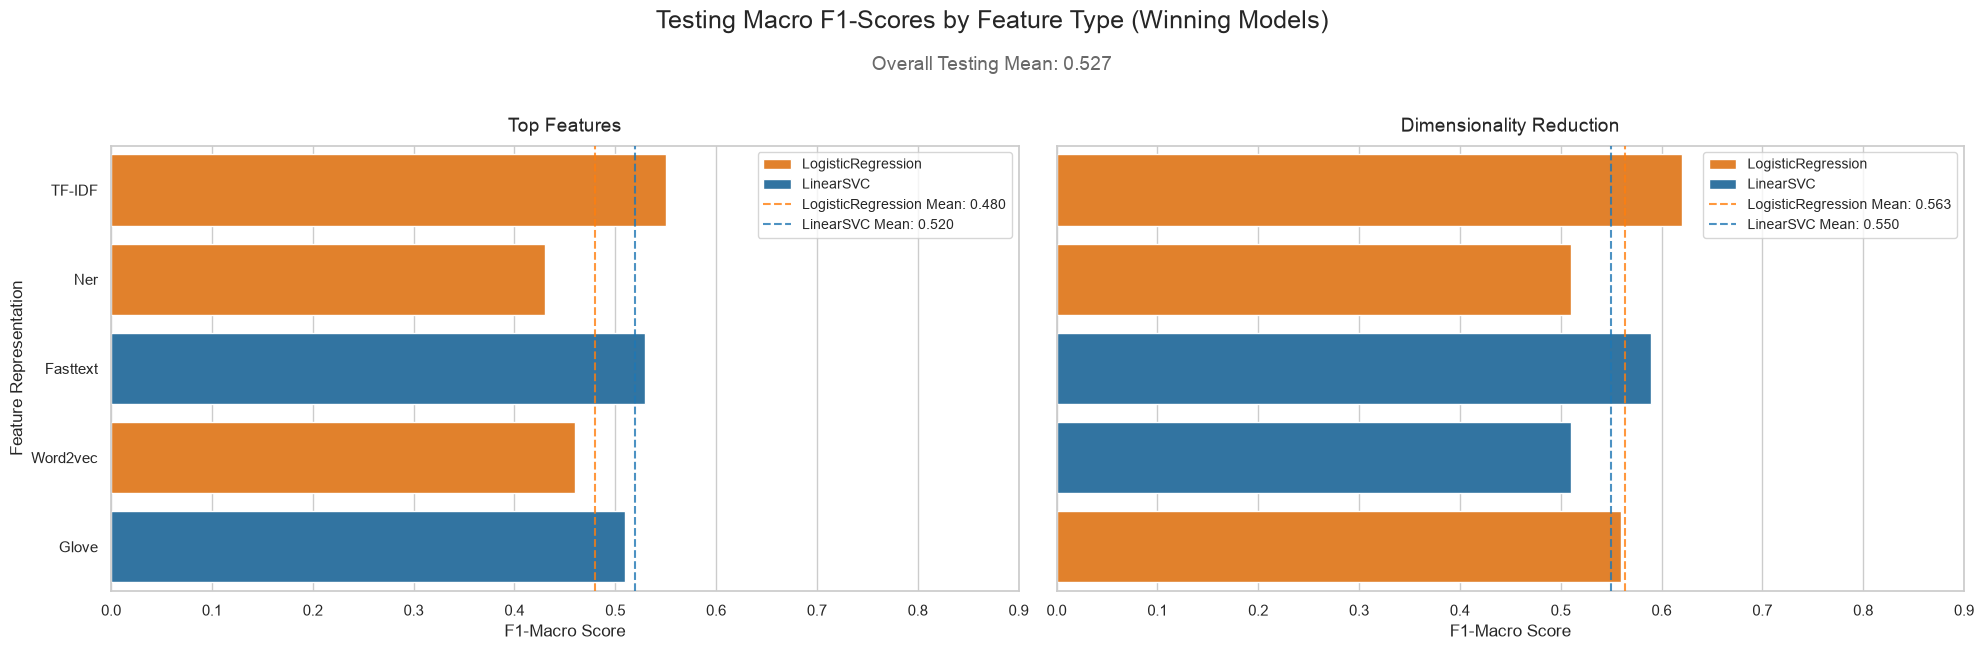

In [13]:
# ==========================================
# PLOT 2: TESTING F1-MACRO SCORES
# ==========================================
test_df = df[df['mode'] == 'testing'].copy()
overall_test_mean = test_df['f1_macro'].mean()

fig2, axes2 = plt.subplots(1, 2, figsize=(20, 6), sharey=True)

# Main Title and Overall Mean Caption
fig2.suptitle('Testing Macro F1-Scores by Feature Type (Winning Models)', fontsize=18, y=1.08)
fig2.text(0.5, 0.98, f"Overall Testing Mean: {overall_test_mean:.3f}", ha='center', fontsize=14, color='dimgray')

for idx, proc_type in enumerate(['Top Features', 'Dimensionality Reduction']):
    subset = test_df[test_df['processing_type'] == proc_type]
    
    # Plot the horizontal bar chart
    sns.barplot(
        data=subset, 
        y='feature_type', 
        x='f1_macro', 
        hue='classifier', 
        palette=clf_palette,
        ax=axes2[idx]
    )
    
    # Calculate and plot the mean vertical line per classifier
    for clf in subset['classifier'].unique():
        clf_mean = subset[subset['classifier'] == clf]['f1_macro'].mean()
        axes2[idx].axvline(
            x=clf_mean, 
            color=clf_palette[clf], 
            linestyle='--', 
            alpha=0.8, 
            zorder=3,
            label=f'{clf} Mean: {clf_mean:.3f}'
        )
    
    # Formatting
    axes2[idx].set_title(proc_type, fontsize=14, pad=10)
    axes2[idx].set_xlabel('F1-Macro Score', fontsize=12)
    axes2[idx].set_xlim(0, 0.9) 
    
    # Safely merge legend handles
    handles, labels = axes2[idx].get_legend_handles_labels()
    axes2[idx].legend(handles, labels, loc='upper right', fontsize=10)

axes2[0].set_ylabel('Feature Representation', fontsize=12)
axes2[1].set_ylabel('')

plt.tight_layout()
plt.savefig(
    "../plots/model_testing_visuals.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

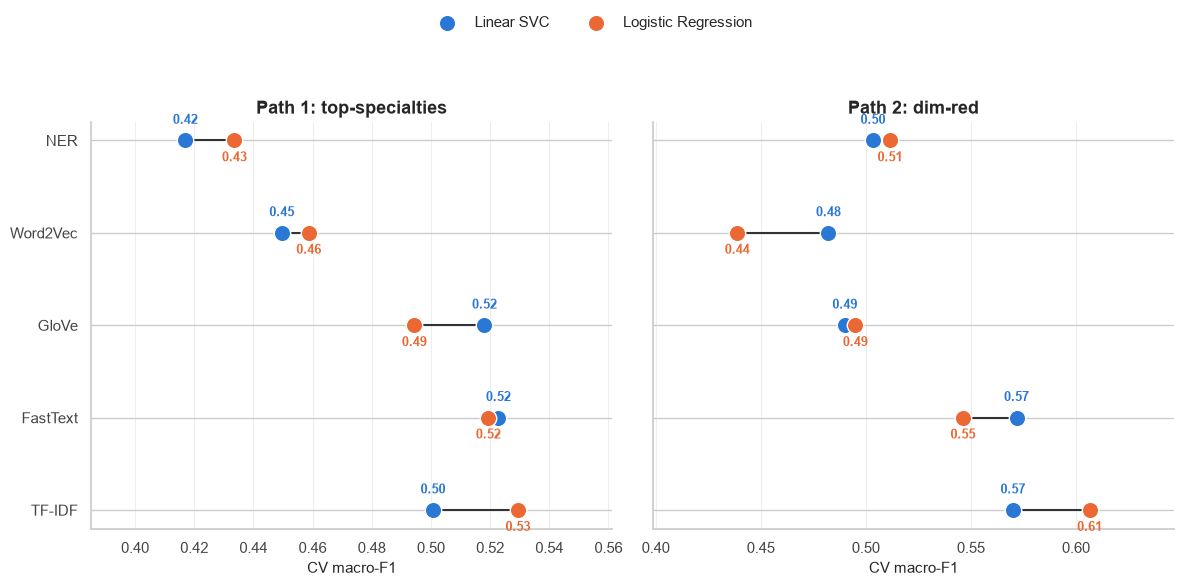

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    ("TF-IDF",    0.5007, 0.5294, 0.57,   0.6065),
    ("FastText",  0.5228, 0.5194, 0.5717, 0.5462),
    ("GloVe",     0.5181, 0.4944, 0.490,  0.495),
    ("Word2Vec",  0.4496, 0.4587, 0.4822, 0.4388),
    ("NER",       0.4170, 0.4336, 0.5034, 0.5115),
]
df = pd.DataFrame(data, columns=["method", "p1_svc", "p1_lr", "p2_svc", "p2_lr"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

panels = [
    (axes[0], "p1_svc", "p1_lr", "Path 1: top-specialties"),
    (axes[1], "p2_svc", "p2_lr", "Path 2: dim-red"),
]

handles = None
for ax, svc_col, lr_col, title in panels:
    y = range(len(df))
    ax.hlines(y, df[svc_col], df[lr_col], color="#333333", linewidth=1.5, zorder=1)
    s1 = ax.scatter(df[svc_col], y, color="#2a78d6", s=140, zorder=3,
                     edgecolor="white", linewidth=1, label="Linear SVC")
    s2 = ax.scatter(df[lr_col], y, color="#eb6834", s=140, zorder=3,
                     edgecolor="white", linewidth=1, label="Logistic Regression")

    for yi, (v_svc, v_lr) in enumerate(zip(df[svc_col], df[lr_col])):
        ax.annotate(f"{v_svc:.2f}", (v_svc, yi), textcoords="offset points",
                    xytext=(0, 12), ha="center", fontsize=9, color="#2a78d6", fontweight="bold")
        ax.annotate(f"{v_lr:.2f}", (v_lr, yi), textcoords="offset points",
                    xytext=(0, -15), ha="center", fontsize=9, color="#eb6834", fontweight="bold")

    ax.set_yticks(y)
    ax.set_yticklabels(df["method"])

    # tighter zoom -> lines visually stretch more
    lo = min(df[svc_col].min(), df[lr_col].min())
    hi = max(df[svc_col].max(), df[lr_col].max())
    pad = (hi - lo) * 0.15 + 0.015   # reduced from 0.35 -> 0.15
    ax.set_xlim(lo - pad, hi + pad)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("CV macro-F1", fontsize=11)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#444444')
    ax.xaxis.grid(True, color="#eeeeee", linewidth=0.8)
    ax.set_axisbelow(True)
    if handles is None:
        handles = [s1, s2]

fig.legend(
    handles=handles,
    labels=["Linear SVC", "Logistic Regression"],
    loc="lower center",
    bbox_to_anchor=(0.5, 1.0),
    ncol=2,
    frameon=False,
    fontsize=11,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("classifier_comparison_dumbbell_v3.png", dpi=200, bbox_inches="tight")

saved


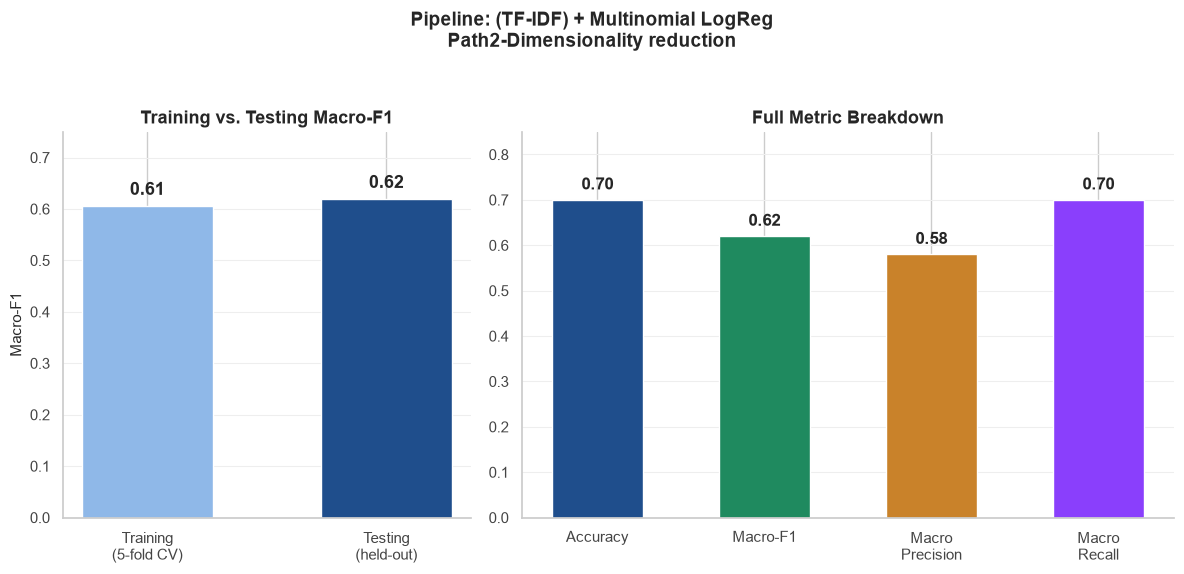

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Best pipeline: TF-IDF (Term Frequency-Inverse Document Frequency)
# + Multinomial Logistic Regression, Path 2 (dimensionality-reduced / broad categories)

# From collected_metrics.csv -> tfidf_dim_red
train_cv_macro_f1 = 0.6065          # training mode, CV macro-F1
test_accuracy      = 0.70
test_macro_f1       = 0.62
test_precision_macro = 0.58
test_recall_macro    = 0.70

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), gridspec_kw={'width_ratios': [1, 1.6]})

# ── Panel A: Train (CV) vs Test macro-F1 — generalization check ──
ax = axes[0]
labels = ['Training\n(5-fold CV)', 'Testing\n(held-out)']
values = [train_cv_macro_f1, test_macro_f1]
colors = ['#8fb8e8', '#1f4e8c']

bars = ax.bar(labels, values, color=colors, width=0.55)
ax.bar_label(bars, fmt='%.2f', fontsize=13, fontweight='bold', padding=5)
ax.set_ylim(0, 0.75)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Training vs. Testing Macro-F1', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors='#444444')

# ── Panel B: Full test-set metric breakdown ──
ax2 = axes[1]
metrics = ['Accuracy', 'Macro-F1', 'Macro\nPrecision', 'Macro\nRecall']
metric_vals = [test_accuracy, test_macro_f1, test_precision_macro, test_recall_macro]
bar_colors = ['#1f4e8c', '#1f8a5f', '#c9822a', '#8a3ffc']

bars2 = ax2.bar(metrics, metric_vals, color=bar_colors, width=0.55)
ax2.bar_label(bars2, fmt='%.2f', fontsize=12, fontweight='bold', padding=5)
ax2.set_ylim(0, 0.85)
ax2.set_title('Full Metric Breakdown', fontsize=13, fontweight='bold')
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.yaxis.grid(True, color='#eeeeee', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.tick_params(colors='#444444')

fig.suptitle(
    'Pipeline: (TF-IDF) + Multinomial LogReg\n'
    'Path2-Dimensionality reduction',
    fontsize=14, fontweight='bold', y=1.04
)

plt.tight_layout()
plt.savefig('best_model_train_vs_test.png', dpi=200, bbox_inches='tight')
print("saved")